# Elastic Net sandbox

Grid-search Elastic Net in place of the Linear Regression workflow, then evaluate per-marker dt R² and ODE-integrated R² (median across markers) for each (alpha, l1_ratio) pair.

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path so experimental.* imports work when running from the notebook dir
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
from sklearn.exceptions import ConvergenceWarning
import warnings
from src.experimental.sr_pipeline import compute_marker_integration as cmi
# Disable Radau fallback to avoid stiff/degenerate warnings; force simple fallback
cmi.solve_ivp = None
# Soften integration/fit warnings to avoid spam during grid
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)


In [3]:
import itertools
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sympy as sp
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.experimental.sr_pipeline.run_functional_groups import (
    choose_bin_split,
    sanitize_feature_names,
    select_features,
    EXCLUDE_COLUMNS,
 )
from experimental.sr_pipeline.compute_marker_integration import (
    ODE_DERIV_MARGIN_FRAC,
    ODE_DERIV_PERCENTILES,
    ODE_FEATURE_CLIP,
    ODE_STATE_MARGIN_FRAC,
    ODE_STATE_PERCENTILES,
    ODE_TSIT5_STATE_MAX,
    ODE_TSIT5_STATE_MIN,
    StateTransform,
    integrate_marker_ode,
    integrate_single_marker,
    make_formula_function,
    prepare_sr_dataset,
    sanitize_formula,
    _compute_percentile_interval,
 )


In [4]:
# === Config ===
dataset_path = Path("../data/experimental/processed/functional_groups/functional_groups_per_minute_fit.csv")
dataset_mode = "per_minute"  # or "snapshot"
measured_timepoints = (0.0, 5.0, 10.0, 15.0, 30.0, 60.0)
test_size = 0.2
random_state = 0

# Elastic Net grid
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
l1_ratios = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

# Optional marker subset (None means all)
marker_filter: Optional[Sequence[str]] = None

In [5]:

# === Helpers ===
def _format_formula(coefs: np.ndarray, names: Sequence[str], intercept: float) -> sp.Expr:
    expr = sp.Float(intercept)
    for c, n in zip(coefs, names):
        expr += sp.Float(c) * sp.Symbol(n)
    return expr


def _eval_marker(
    df: pd.DataFrame,
    marker: str,
    feature_columns: List[str],
    alpha: float,
    l1_ratio: float,
    dataset_mode: str,
    measured_timepoints: Sequence[float],
    random_state: int,
    test_size: float,
) -> Tuple[Optional[float], Optional[float]]:
    subset = df[df["marker"] == marker].copy()
    subset = subset.dropna(subset=feature_columns + ["p_ERK1_2_dt", "GFP_bin", "timepoint"])
    if subset.empty:
        return None, None

    train_bins, test_bins = choose_bin_split(subset, test_size=test_size, random_state=random_state)
    if not train_bins or not test_bins:
        return None, None
    train_df = subset[subset["GFP_bin"].isin(train_bins)].copy()
    test_df = subset[subset["GFP_bin"].isin(test_bins)].copy()
    if dataset_mode == "per_minute":
        time_arr = pd.to_numeric(test_df.get("timepoint"), errors="coerce").to_numpy()
        measured_mask = np.isin(time_arr, measured_timepoints)
        measured_count = int(np.isfinite(time_arr[measured_mask]).sum())
    else:
        measured_count = len(test_df)
    print(f"[split] {marker}: train={len(train_df)} | test_raw={len(test_df)} | test_measured={measured_count}")
    if train_df.empty or test_df.empty:
        return None, None

    # Fit Elastic Net (with scaling)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=2000, random_state=random_state)),
    ])
    X_train = train_df[feature_columns].to_numpy(dtype=float)
    y_train = train_df["p_ERK1_2_dt"].to_numpy(dtype=float)
    X_test = test_df[feature_columns].to_numpy(dtype=float)
    y_test = test_df["p_ERK1_2_dt"].to_numpy(dtype=float)
    pipeline.fit(X_train, y_train)
    y_pred_test = pipeline.predict(X_test)

    # Build formula expression using sanitized names
    model = pipeline.named_steps["model"]
    coefs = model.coef_
    intercept = model.intercept_
    expr = _format_formula(coefs, feature_columns, intercept)
    expr = sanitize_formula(expr, safe_division_eps=None)
    formula_fn_np, symbols = make_formula_function(expr, backend="numpy")

    def _prepare_eval(frame: pd.DataFrame, preds: np.ndarray, phase: str) -> pd.DataFrame:
        f = frame.copy()
        f["__y_pred__"] = preds
        f["phase"] = phase
        return f

    train_eval = _prepare_eval(train_df, pipeline.predict(X_train), "train")
    test_eval = _prepare_eval(test_df, y_pred_test, "test")

    # State/derivative bounds from training data
    obs_p_raw = train_eval.get("p_ERK1_2", train_eval.get("p-ERK1-2"))
    if obs_p_raw is None:
        obs_p_raw = pd.Series(np.nan, index=train_eval.index)
    obs_p = pd.to_numeric(obs_p_raw, errors="coerce")
    state_bounds = _compute_percentile_interval(
        obs_p.to_numpy(dtype=float),
        ODE_STATE_PERCENTILES,
        ODE_STATE_MARGIN_FRAC,
        (ODE_TSIT5_STATE_MIN, ODE_TSIT5_STATE_MAX),
    )
    state_transform = StateTransform("identity", state_bounds)
    preds_dt_train = pipeline.predict(X_train)
    deriv_clip = _compute_percentile_interval(
        preds_dt_train,
        ODE_DERIV_PERCENTILES,
        ODE_DERIV_MARGIN_FRAC,
        (-1e6, 1e6),
    )

    # dt/integrated metrics on test split
    metrics_dt, _ = integrate_single_marker(
        test_eval,
        "p_ERK1_2_dt",
        measured_timepoints,
        dataset_mode,
        include_trajectories=False,
        phase="test",
    )

    obs_p_cols = [c for c in ("p_ERK1_2", "p-ERK1-2") if c in test_eval.columns]
    print(
        f"[ode debug] {marker} | obs_p_cols={obs_p_cols} | "
        f"finite_obs_p={int(np.isfinite(test_eval.get(obs_p_cols[0], np.nan)).sum())}"
    )

    ode_metrics, ode_trajs = integrate_marker_ode(
        test_eval,
        "p_ERK1_2_dt",
        measured_timepoints,
        dataset_mode,
        formula_fn_np,
        symbols,
        sanitize_feature_names(["p_ERK1_2"])[0],
        formula_fn_fallback=formula_fn_np,
        feature_clip_percentiles=ODE_FEATURE_CLIP,
        anchor_alpha=0.0,
        anchor_adaptive_scale=0.0,
        state_transform=state_transform,
        deriv_clip=deriv_clip,
        prefer_radau=False,
        include_trajectories=True,
        phase="test",
    )
    ode_r2 = ode_metrics.get("ode_integ_r2_median")
    if ode_r2 is None or (isinstance(ode_r2, float) and np.isnan(ode_r2)):
        try:
            df_traj = pd.DataFrame(ode_trajs)
            df_traj = df_traj[df_traj["phase"] == "test"] if "phase" in df_traj else df_traj
            obs = pd.to_numeric(df_traj.get("obs_pERK1_2"), errors="coerce")
            pred = pd.to_numeric(df_traj.get("pred_integrated_ode"), errors="coerce")
            tvals = pd.to_numeric(df_traj.get("timepoint"), errors="coerce")
            mask = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(tvals)
            if dataset_mode == "per_minute":
                mask = mask & np.isin(tvals, measured_timepoints)
            if mask.sum() >= 2:
                ode_r2 = float(np.corrcoef(obs[mask], pred[mask])[0, 1] ** 2)
        except Exception:
            ode_r2 = ode_metrics.get("ode_integ_r2_median")

    return metrics_dt.get("dt_r2"), ode_r2


In [6]:
# === Load dataset and run grid ===
raw_df = pd.read_csv(dataset_path)
df, target_col = prepare_sr_dataset(raw_df)
candidate_cols = [c for c in df.columns if c not in EXCLUDE_COLUMNS]
feature_columns = select_features(df, "all")

feature_columns = sanitize_feature_names([c for c in feature_columns if c != target_col])

print(feature_columns)
p_cols = [c for c in ("p-ERK1-2", "p_ERK1_2") if c in df.columns]
p_col = p_cols[0] if p_cols else None

# Keep features + metadata + target (+ p column if present), avoid duplicate column names
cols_to_keep = [*feature_columns, "marker", "GFP_bin", "timepoint", target_col]
if p_col:
    cols_to_keep.append(p_col)
df = df[cols_to_keep].copy()
df = df.loc[:, ~df.columns.duplicated()]  # drop any duplicate-named columns

markers = sorted(df["marker"].dropna().unique().tolist())
if marker_filter:
    markers = [m for m in markers if m in marker_filter]

records: List[Dict[str, object]] = []

for alpha, l1 in itertools.product(alphas, l1_ratios):
    dt_scores: List[float] = []
    ode_scores: List[float] = []
    for marker in markers:
        dt_r2, ode_r2 = _eval_marker(
            df,
            marker,
            feature_columns,
            alpha,
            l1,
            dataset_mode,
            measured_timepoints,
            random_state,
            test_size,
        )
        if dt_r2 is not None:
            dt_scores.append(dt_r2)
        if ode_r2 is not None:
            ode_scores.append(ode_r2)

    records.append(
        {
            "alpha": alpha,
            "l1_ratio": l1,
            "dt_r2_median": np.median(dt_scores) if dt_scores else np.nan,
            "ode_r2_median": np.median(ode_scores) if ode_scores else np.nan,
        }
    )

grid_df = pd.DataFrame(records)
grid_df


['GFP', 'p_ERK1_2', 'p_ERK1_2_min', 'p_MEK1_2', 'p_MEK1_2_min', 'p_RAF', 'p_p90RSK', 'p_MAPKAPK2', 'p_PDK1', 'p_MKK3_6']
[split] ABL1: train=610 | test_raw=122 | test_measured=12
[ode debug] ABL1 | obs_p_cols=['p_ERK1_2'] | finite_obs_p=122
[split] AKT3: train=2440 | test_raw=610 | test_measured=60
[ode debug] AKT3 | obs_p_cols=['p_ERK1_2'] | finite_obs_p=610
[split] ALPK2: train=2379 | test_raw=610 | test_measured=60
[ode debug] ALPK2 | obs_p_cols=['p_ERK1_2'] | finite_obs_p=610
[split] ARAF: train=1830 | test_raw=427 | test_measured=42
[ode debug] ARAF | obs_p_cols=['p_ERK1_2'] | finite_obs_p=427
[split] DUSP10 (P2): train=2013 | test_raw=488 | test_measured=48
[ode debug] DUSP10 (P2) | obs_p_cols=['p_ERK1_2'] | finite_obs_p=488
[split] DUSP16: train=2257 | test_raw=549 | test_measured=54
[ode debug] DUSP16 | obs_p_cols=['p_ERK1_2'] | finite_obs_p=549
[split] DUSP4: train=2318 | test_raw=549 | test_measured=54
[ode debug] DUSP4 | obs_p_cols=['p_ERK1_2'] | finite_obs_p=549
[split] DUS

,alpha,l1_ratio,dt_r2_median,ode_r2_median
0,0.00001,0.01,0.594244,0.373107
1,0.00001,0.10,0.594241,0.373043
2,0.00001,0.30,0.594235,0.372889
3,0.00001,0.50,0.594228,0.372772
4,0.00001,0.70,0.594221,0.372518
5,0.00001,0.90,0.594214,0.372474
6,0.00001,1.00,0.594211,0.372441
7,0.00010,0.01,0.594201,0.370929
8,0.00010,0.10,0.594169,0.370310
9,0.00010,0.30,0.594090,0.369450


In [7]:
# Diagnostics: list bins dropped (and why) before dt predictions
drop_records = []
required_cols = feature_columns + ["p_ERK1_2_dt", "GFP_bin", "timepoint"]
for marker in markers:
    raw_marker = df[df["marker"] == marker].copy()
    for b in sorted(raw_marker["GFP_bin"].dropna().unique()):
        g_raw = raw_marker[raw_marker["GFP_bin"] == b].copy()
        n_raw = len(g_raw)
        missing_target = g_raw["p_ERK1_2_dt"].isna().sum()
        missing_time = g_raw["timepoint"].isna().sum()
        missing_features = g_raw[feature_columns].isna().any(axis=1).sum()
        g_drop = g_raw.dropna(subset=required_cols)
        n_after_drop = len(g_drop)
        measured_removed = 0
        if dataset_mode == "per_minute":
            time_arr = pd.to_numeric(g_drop.get("timepoint"), errors="coerce").to_numpy()
            mask_measured = np.isin(time_arr, measured_timepoints)
            measured_removed = int((~mask_measured).sum())
            g_drop = g_drop[mask_measured]
        n_final = len(g_drop)
        status = "kept" if n_final > 0 else "dropped"
        reason_parts = []
        if missing_target:
            reason_parts.append(f"{missing_target} rows missing target")
        if missing_time:
            reason_parts.append(f"{missing_time} rows missing time")
        if missing_features:
            reason_parts.append(f"{missing_features} rows missing features")
        if measured_removed:
            reason_parts.append(f"{measured_removed} rows dropped by measured-timepoints filter")
        reason = "; ".join(reason_parts) if reason_parts else "ok"
        drop_records.append(
            {
                "marker": marker,
                "GFP_bin": b,
                "rows_raw": n_raw,
                "rows_after_dropna": n_after_drop,
                "rows_final": n_final,
                "status": status,
                "reason": reason,
            }
        )

drop_df = pd.DataFrame(drop_records)
dropped = drop_df[drop_df["status"] == "dropped"].copy()
print(f"Bins dropped: {len(dropped)} / {len(drop_df)}")
display(dropped.head(50))
if not dropped.empty:
    # Optional: save detailed drop report
    dropped.to_csv("elastic_net_bin_drop_report.csv", index=False)


Bins dropped: 393 / 1928


,marker,GFP_bin,rows_raw,rows_after_dropna,rows_final,status,reason
0,ABL1,0,61,0,0,dropped,61 rows missing target; 61 rows missing features
2,ABL1,2,61,0,0,dropped,61 rows missing target; 61 rows missing features
13,ABL1,13,61,0,0,dropped,61 rows missing target; 61 rows missing features
14,ABL1,14,61,0,0,dropped,61 rows missing target; 61 rows missing features
15,ABL1,15,61,0,0,dropped,61 rows missing target; 61 rows missing features
16,ABL1,16,61,0,0,dropped,61 rows missing target; 61 rows missing features
17,ABL1,17,61,0,0,dropped,61 rows missing target; 61 rows missing features
18,ABL1,18,61,0,0,dropped,61 rows missing target; 61 rows missing features
19,ABL1,19,61,0,0,dropped,61 rows missing target; 61 rows missing features
20,ABL1,20,61,0,0,dropped,61 rows missing target; 61 rows missing features


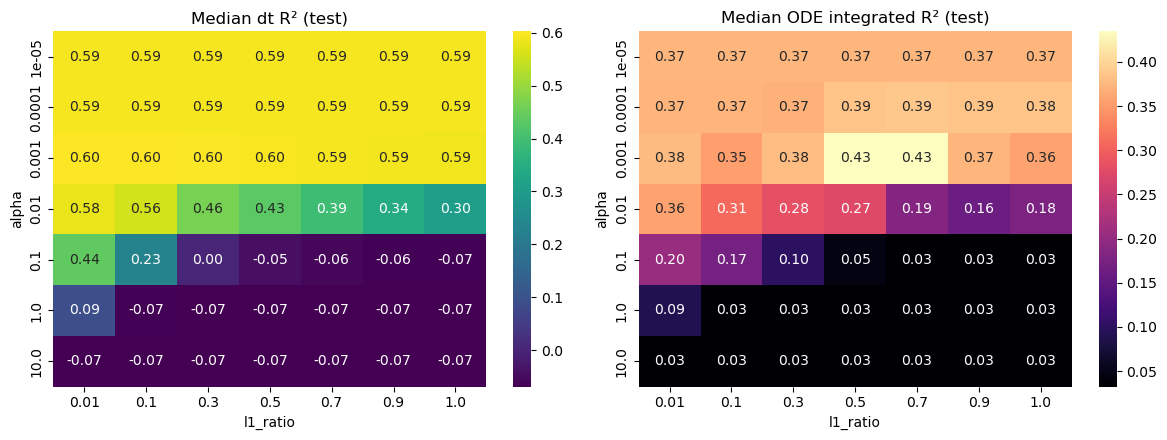

In [8]:
# === Heatmaps ===
if not grid_df.empty:
    pivot_dt = grid_df.pivot(index="alpha", columns="l1_ratio", values="dt_r2_median")
    pivot_ode = grid_df.pivot(index="alpha", columns="l1_ratio", values="ode_r2_median")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(pivot_dt, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
    axes[0].set_title("Median dt R² (test)")
    sns.heatmap(pivot_ode, annot=True, fmt=".2f", cmap="magma", ax=axes[1])
    axes[1].set_title("Median ODE integrated R² (test)")
    fig.tight_layout()
else:
    print("Grid results empty; check dataset/marker filtering.")

Best config: alpha=0.001, l1_ratio=0.70, ode_r2_median=0.4345688760260931, dt_r2_median=0.5933285463844309


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_22812/2977899942.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  low_colors = cm.get_cmap('Blues')(np.linspace(0.15, 1.0, max(2, n_low)))
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_22812/2977899942.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  high_colors = cm.get_cmap('plasma')(np.linspace(0.35, 1.0, max(2, n_high)))


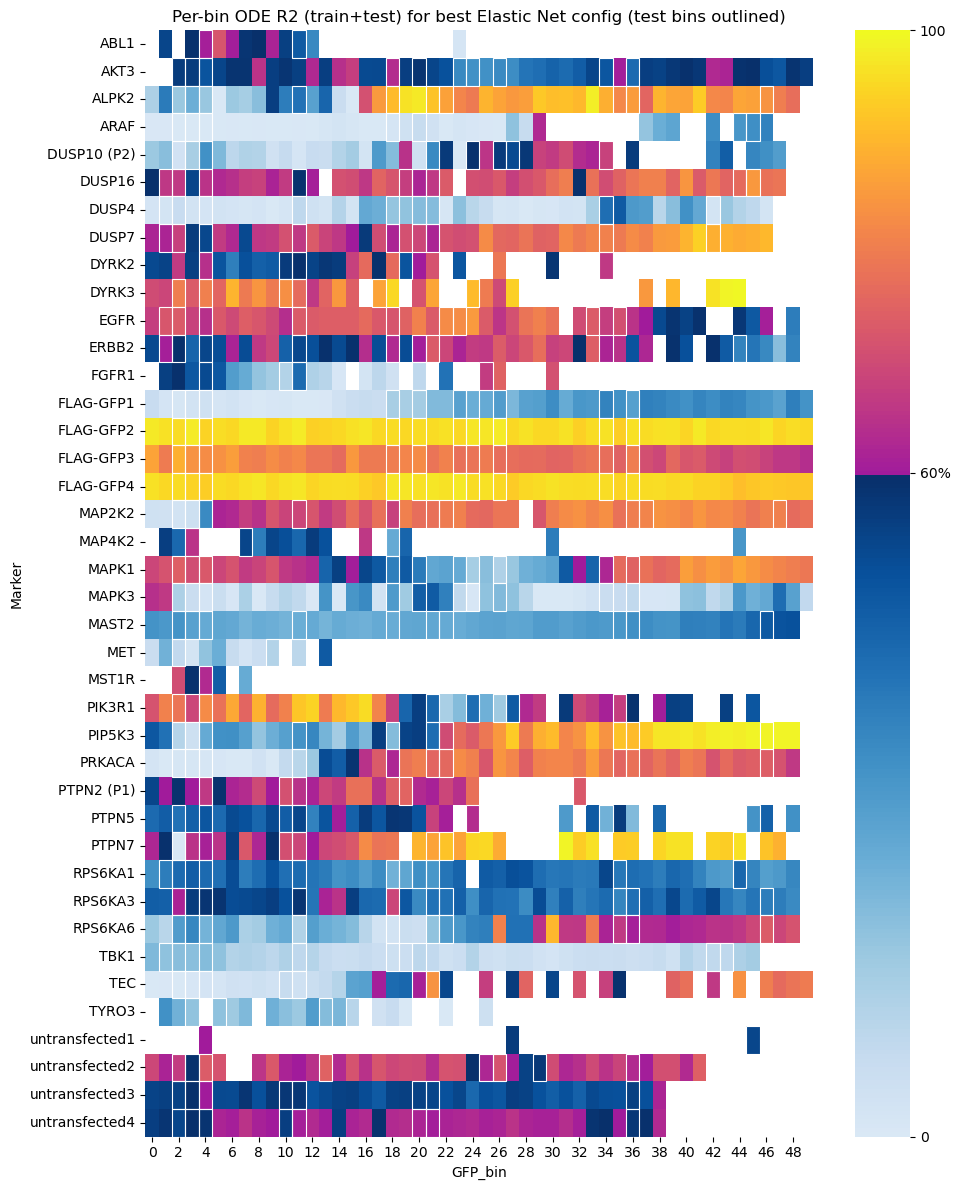

In [9]:
import numpy as np
from matplotlib import cm, colors as mcolors

# Heatmap: per-bin ODE R2 for best (alpha, l1_ratio), showing train+test; test bins outlined
best = grid_df.dropna(subset=['ode_r2_median'])
if best.empty:
    best = grid_df.dropna(subset=['dt_r2_median'])
if best.empty:
    print('No grid results available.')
else:
    best_row = best.sort_values('ode_r2_median', ascending=False).iloc[0]
    best_alpha = float(best_row['alpha'])
    best_l1 = float(best_row['l1_ratio'])
    print('Best config: alpha={:.4g}, l1_ratio={:.2f}, ode_r2_median={}, dt_r2_median={}'.format(
        best_alpha, best_l1, best_row.get('ode_r2_median'), best_row.get('dt_r2_median'))
    )

    bin_records = []
    p_symbol = sanitize_feature_names(['p_ERK1_2'])[0]

    for marker in markers:
        subset = df[df['marker'] == marker].copy()
        subset = subset.dropna(subset=feature_columns + ['p_ERK1_2_dt', 'GFP_bin', 'timepoint'])
        if subset.empty:
            continue

        # Split bins for train/test masks to draw outlines; evaluate on all bins
        bins_split = choose_bin_split(subset, test_size=test_size, random_state=random_state)
        train_bins = bins_split[0] or set()
        test_bins_set = bins_split[1] or set()

        eval_df = subset.copy()
        if dataset_mode == 'per_minute':
            time_arr = pd.to_numeric(eval_df.get('timepoint'), errors='coerce').to_numpy()
            mask_measured = np.isin(time_arr, measured_timepoints)
            eval_df = eval_df[mask_measured] if mask_measured.any() else eval_df.iloc[:0]
        if eval_df.empty:
            continue

        pipe = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=2000, random_state=random_state))])
        X_all = eval_df[feature_columns].to_numpy(dtype=float)
        y_all = eval_df['p_ERK1_2_dt'].to_numpy(dtype=float)
        pipe.fit(X_all, y_all)
        y_pred = pipe.predict(X_all)

        model = pipe.named_steps['model']
        expr = _format_formula(model.coef_, feature_columns, model.intercept_)
        expr = sanitize_formula(expr, safe_division_eps=None)
        formula_fn_np, symbols = make_formula_function(expr, backend='numpy')

        eval_df = eval_df.copy()
        eval_df['__y_pred__'] = y_pred
        eval_df['phase'] = 'all'

        obs_p_raw = eval_df.get('p_ERK1_2', eval_df.get('p-ERK1-2'))
        obs_p = pd.to_numeric(obs_p_raw, errors='coerce') if obs_p_raw is not None else pd.Series(np.nan, index=eval_df.index)
        state_bounds = _compute_percentile_interval(obs_p.to_numpy(dtype=float), ODE_STATE_PERCENTILES, ODE_STATE_MARGIN_FRAC, (ODE_TSIT5_STATE_MIN, ODE_TSIT5_STATE_MAX))
        state_transform = StateTransform('identity', state_bounds)
        deriv_clip = _compute_percentile_interval(pipe.predict(X_all), ODE_DERIV_PERCENTILES, ODE_DERIV_MARGIN_FRAC, (-1e6, 1e6))

        _, ode_trajs = integrate_marker_ode(
            eval_df,
            'p_ERK1_2_dt',
            measured_timepoints,
            dataset_mode,
            formula_fn_np,
            symbols,
            p_symbol,
            formula_fn_fallback=formula_fn_np,
            feature_clip_percentiles=ODE_FEATURE_CLIP,
            anchor_alpha=0.0,
            anchor_adaptive_scale=0.0,
            state_transform=state_transform,
            deriv_clip=deriv_clip,
            prefer_radau=False,
            include_trajectories=True,
            phase='all',
        )
        df_traj = pd.DataFrame(ode_trajs)
        if df_traj.empty:
            continue
        if 'phase' in df_traj.columns:
            df_traj = df_traj[df_traj['phase'] == 'all']
        for b, g in df_traj.groupby('GFP_bin'):
            obs = pd.to_numeric(g.get('obs_pERK1_2'), errors='coerce')
            pred = pd.to_numeric(g.get('pred_integrated_ode'), errors='coerce')
            tvals = pd.to_numeric(g.get('timepoint'), errors='coerce')
            mask = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(tvals)
            if dataset_mode == 'per_minute':
                mask = mask & np.isin(tvals, measured_timepoints)
            if mask.sum() >= 2:
                r2 = float(np.corrcoef(obs[mask], pred[mask])[0, 1] ** 2)
                bin_records.append({'marker': marker, 'GFP_bin': b, 'ode_r2': r2, 'is_test': b in test_bins_set})

    if bin_records:
        bin_df = pd.DataFrame(bin_records)
        heat = bin_df.pivot(index='marker', columns='GFP_bin', values='ode_r2')
        plt.figure(figsize=(10, max(6, len(heat) * 0.3)))
        # compose a colormap that makes bottom 70% visually distinct from top 30%
        thresh = 0.6
        N = 256
        n_low = int(N * thresh)
        n_high = N - n_low

        # muted/cool colors for bottom 70%, bright/warm for top 30%
        low_colors = cm.get_cmap('Blues')(np.linspace(0.15, 1.0, max(2, n_low)))
        high_colors = cm.get_cmap('plasma')(np.linspace(0.35, 1.0, max(2, n_high)))

        # concatenate so the transition at `thresh` is clear
        combined = np.vstack((low_colors, high_colors))
        custom_cmap = mcolors.LinearSegmentedColormap.from_list('bottom70_top30', combined, N=N)

        ax = sns.heatmap(heat, annot=False, cmap=custom_cmap, vmin=0, vmax=1, cbar=True, linewidths=0.0, linecolor=None)

        # make the colorbar show the threshold tick for clarity
        try:
            cb = ax.collections[0].colorbar
            cb.set_ticks([0.0, thresh, 1.0])
            cb.set_ticklabels(['0', f'{int(thresh*100)}%', '100'])
        except Exception:
            pass
        for _, row in bin_df.iterrows():
            if row.get('is_test'):
                y = list(heat.index).index(row['marker'])
                x = list(heat.columns).index(row['GFP_bin'])
                ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='white', linewidth=0.8))
        plt.title('Per-bin ODE R2 (train+test) for best Elastic Net config (test bins outlined)')
        plt.xlabel('GFP_bin')
        plt.ylabel('Marker')
        plt.tight_layout()
    else:
        print('No per-bin ODE R2 computed.')


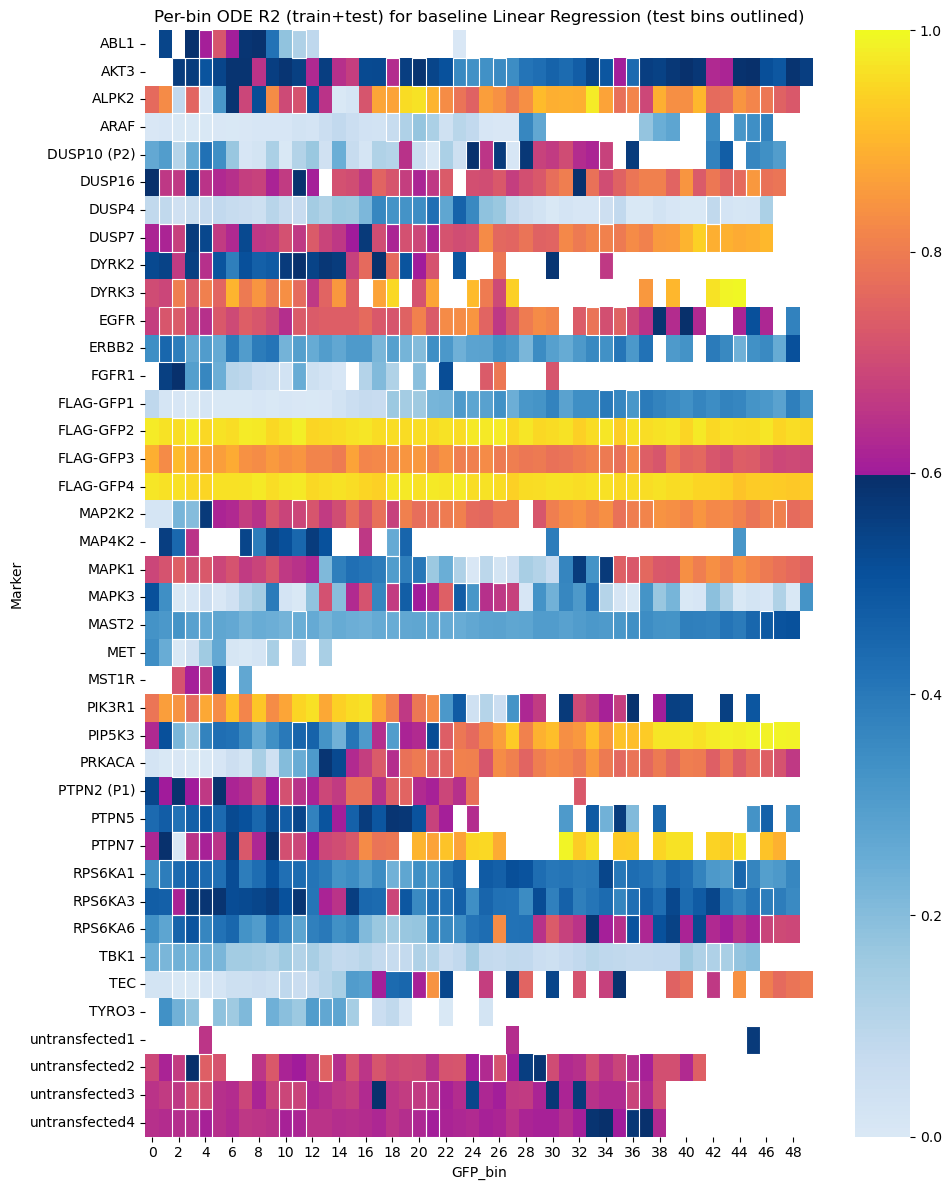

In [10]:
# Heatmap: per-bin ODE R2 for baseline Linear Regression (train+test; test bins outlined)
from sklearn.linear_model import LinearRegression
bin_records = []
p_symbol = sanitize_feature_names(['p_ERK1_2'])[0]

for marker in markers:
    subset = df[df['marker'] == marker].copy()
    subset = subset.dropna(subset=feature_columns + ['p_ERK1_2_dt', 'GFP_bin', 'timepoint'])
    if subset.empty:
        continue

    bins_split = choose_bin_split(subset, test_size=test_size, random_state=random_state)
    train_bins = bins_split[0] or set()
    test_bins_set = bins_split[1] or set()

    eval_df = subset.copy()
    if dataset_mode == 'per_minute':
        time_arr = pd.to_numeric(eval_df.get('timepoint'), errors='coerce').to_numpy()
        mask_measured = np.isin(time_arr, measured_timepoints)
        eval_df = eval_df[mask_measured] if mask_measured.any() else eval_df.iloc[:0]
    if eval_df.empty:
        continue

    pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
    X_all = eval_df[feature_columns].to_numpy(dtype=float)
    y_all = eval_df['p_ERK1_2_dt'].to_numpy(dtype=float)
    pipe.fit(X_all, y_all)
    y_pred = pipe.predict(X_all)

    model = pipe.named_steps['model']
    expr = _format_formula(model.coef_, feature_columns, model.intercept_)
    expr = sanitize_formula(expr, safe_division_eps=None)
    formula_fn_np, symbols = make_formula_function(expr, backend='numpy')

    eval_df = eval_df.copy()
    eval_df['__y_pred__'] = y_pred
    eval_df['phase'] = 'all'

    obs_p_raw = eval_df.get('p_ERK1_2', eval_df.get('p-ERK1-2'))
    obs_p = pd.to_numeric(obs_p_raw, errors='coerce') if obs_p_raw is not None else pd.Series(np.nan, index=eval_df.index)
    state_bounds = _compute_percentile_interval(obs_p.to_numpy(dtype=float), ODE_STATE_PERCENTILES, ODE_STATE_MARGIN_FRAC, (ODE_TSIT5_STATE_MIN, ODE_TSIT5_STATE_MAX))
    state_transform = StateTransform('identity', state_bounds)
    deriv_clip = _compute_percentile_interval(pipe.predict(X_all), ODE_DERIV_PERCENTILES, ODE_DERIV_MARGIN_FRAC, (-1e6, 1e6))

    _, ode_trajs = integrate_marker_ode(
        eval_df,
        'p_ERK1_2_dt',
        measured_timepoints,
        dataset_mode,
        formula_fn_np,
        symbols,
        p_symbol,
        formula_fn_fallback=formula_fn_np,
        feature_clip_percentiles=ODE_FEATURE_CLIP,
        anchor_alpha=0.0,
        anchor_adaptive_scale=0.0,
        state_transform=state_transform,
        deriv_clip=deriv_clip,
        prefer_radau=False,
        include_trajectories=True,
        phase='all',
    )
    df_traj = pd.DataFrame(ode_trajs)
    if df_traj.empty:
        continue
    if 'phase' in df_traj.columns:
        df_traj = df_traj[df_traj['phase'] == 'all']
    for b, g in df_traj.groupby('GFP_bin'):
        obs = pd.to_numeric(g.get('obs_pERK1_2'), errors='coerce')
        pred = pd.to_numeric(g.get('pred_integrated_ode'), errors='coerce')
        tvals = pd.to_numeric(g.get('timepoint'), errors='coerce')
        mask = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(tvals)
        if dataset_mode == 'per_minute':
            mask = mask & np.isin(tvals, measured_timepoints)
        if mask.sum() >= 2:
            r2 = float(np.corrcoef(obs[mask], pred[mask])[0, 1] ** 2)
            bin_records.append({'marker': marker, 'GFP_bin': b, 'ode_r2': r2, 'is_test': b in test_bins_set})

if bin_records:
    bin_df = pd.DataFrame(bin_records)
    heat = bin_df.pivot(index='marker', columns='GFP_bin', values='ode_r2')
    plt.figure(figsize=(10, max(6, len(heat) * 0.3)))
    ax = sns.heatmap(heat, annot=False, cmap=custom_cmap, vmin=0, vmax=1, cbar=True, linewidths=0.0, linecolor=None)
    for _, row in bin_df.iterrows():
        if row.get('is_test'):
            y = list(heat.index).index(row['marker'])
            x = list(heat.columns).index(row['GFP_bin'])
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='white', linewidth=0.8))
    plt.title('Per-bin ODE R2 (train+test) for baseline Linear Regression (test bins outlined)')
    plt.xlabel('GFP_bin')
    plt.ylabel('Marker')
    plt.tight_layout()
else:
    print('No per-bin ODE R2 computed for Linear Regression.')


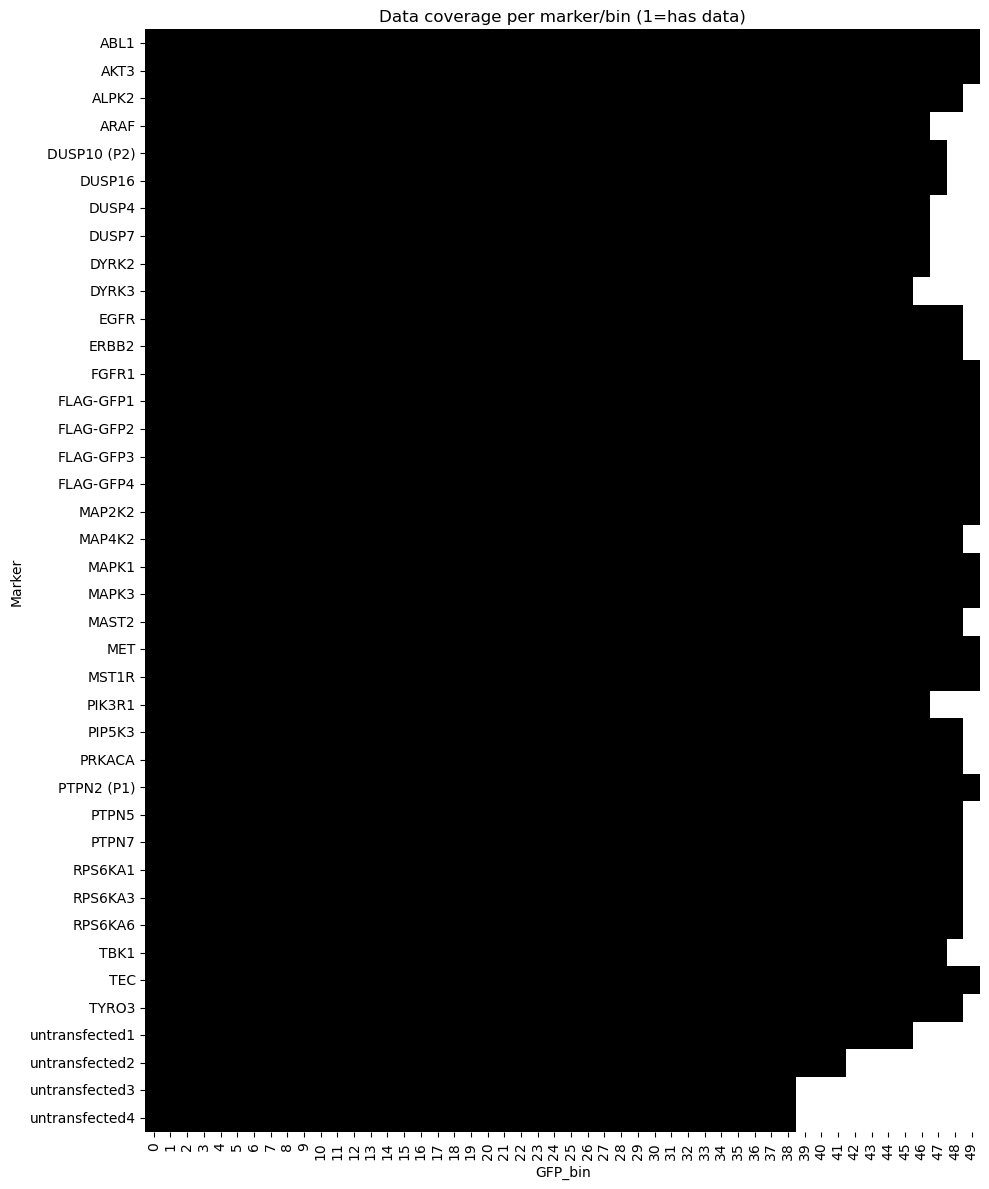

In [11]:
# Binary coverage heatmap: presence of data per marker/bin (pre-integration)
coverage = []
for marker in markers:
    subset = df[df['marker'] == marker].copy()
    subset = subset.dropna(subset=['GFP_bin', 'timepoint'])
    for b in subset['GFP_bin'].dropna().unique():
        coverage.append({'marker': marker, 'GFP_bin': b, 'has_data': 1})

if coverage:
    cov_df = pd.DataFrame(coverage)
    heat = cov_df.pivot(index='marker', columns='GFP_bin', values='has_data').fillna(0)
    plt.figure(figsize=(10, max(6, len(heat) * 0.3)))
    sns.heatmap(heat, annot=False, cmap='Greys', cbar=False)
    plt.title('Data coverage per marker/bin (1=has data)')
    plt.xlabel('GFP_bin')
    plt.ylabel('Marker')
    plt.tight_layout()
else:
    print('No data coverage to plot.')


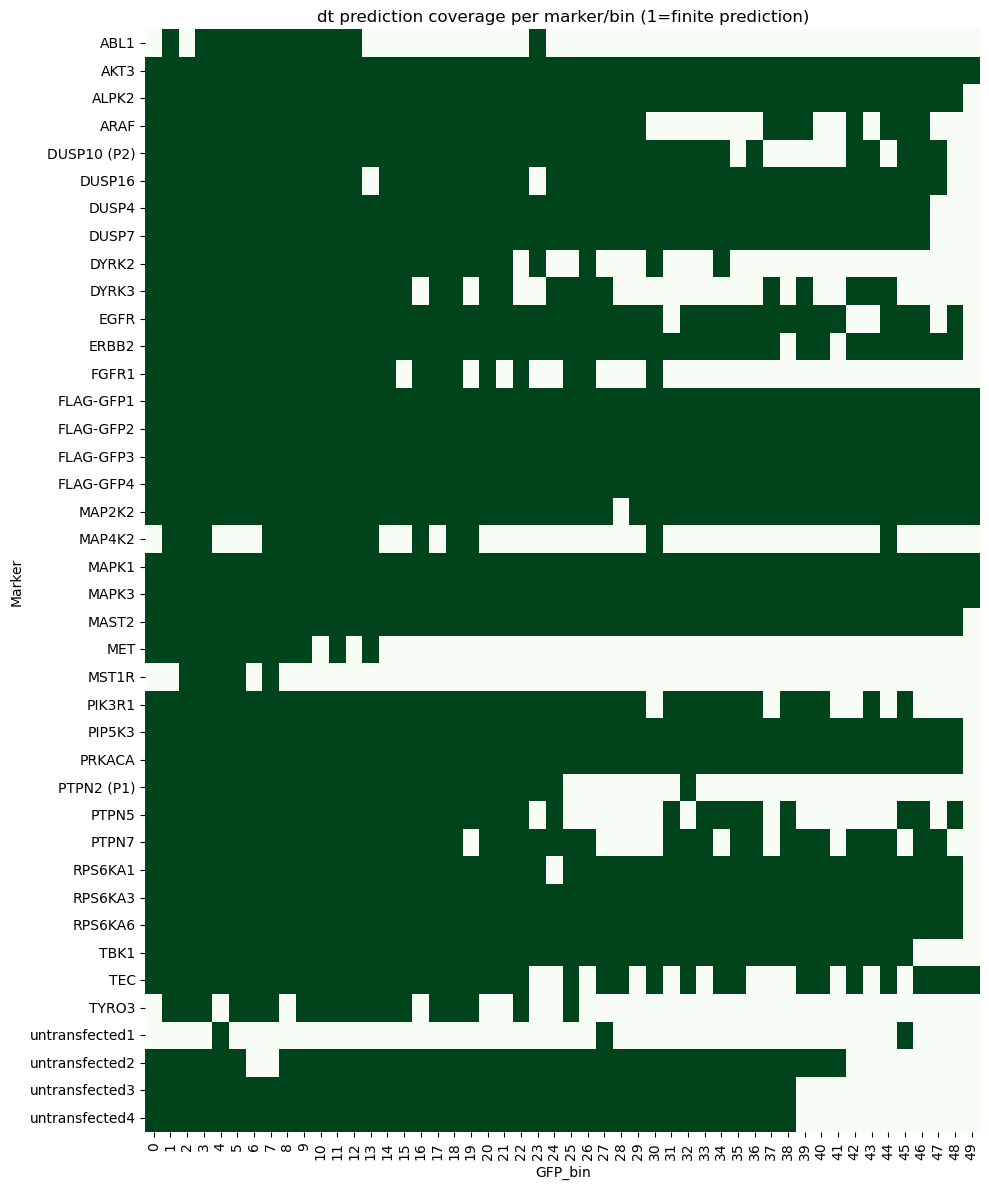

In [12]:
# Binary heatmap: coverage of finite dt predictions per marker/bin (best Elastic Net)
if grid_df.empty or markers == []:
    print('No grid results/markers to compute dt coverage.')
else:
    best = grid_df.dropna(subset=['ode_r2_median'])
    if best.empty:
        best = grid_df.dropna(subset=['dt_r2_median'])
    if best.empty:
        print('No valid grid rows to choose best config for dt coverage.')
    else:
        best_row = best.sort_values('ode_r2_median', ascending=False).iloc[0]
        best_alpha = float(best_row['alpha'])
        best_l1 = float(best_row['l1_ratio'])
        cov_records = []
        for marker in markers:
            subset = df[df['marker'] == marker].copy()
            subset = subset.dropna(subset=feature_columns + ['p_ERK1_2_dt', 'GFP_bin', 'timepoint'])
            if subset.empty:
                continue
            eval_df = subset.copy()
            if dataset_mode == 'per_minute':
                time_arr = pd.to_numeric(eval_df.get('timepoint'), errors='coerce').to_numpy()
                mask_measured = np.isin(time_arr, measured_timepoints)
                eval_df = eval_df[mask_measured] if mask_measured.any() else eval_df.iloc[:0]
            if eval_df.empty:
                continue
            pipe = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=2000, random_state=random_state))])
            X_all = eval_df[feature_columns].to_numpy(dtype=float)
            y_all = eval_df['p_ERK1_2_dt'].to_numpy(dtype=float)
            pipe.fit(X_all, y_all)
            y_pred = pipe.predict(X_all)
            eval_df['__y_pred__'] = y_pred
            # Finite predictions per bin
            for b, g in eval_df.groupby('GFP_bin'):
                preds = g['__y_pred__'].to_numpy(dtype=float)
                if np.isfinite(preds).any():
                    cov_records.append({'marker': marker, 'GFP_bin': b, 'has_pred': 1})
        if cov_records:
            cov_df = pd.DataFrame(cov_records)
            heat = cov_df.pivot(index='marker', columns='GFP_bin', values='has_pred').fillna(0)
            plt.figure(figsize=(10, max(6, len(heat) * 0.3)))
            sns.heatmap(heat, annot=False, cmap='Greens', cbar=False)
            plt.title('dt prediction coverage per marker/bin (1=finite prediction)')
            plt.xlabel('GFP_bin')
            plt.ylabel('Marker')
            plt.tight_layout()
        else:
            print('No finite dt predictions to plot.')


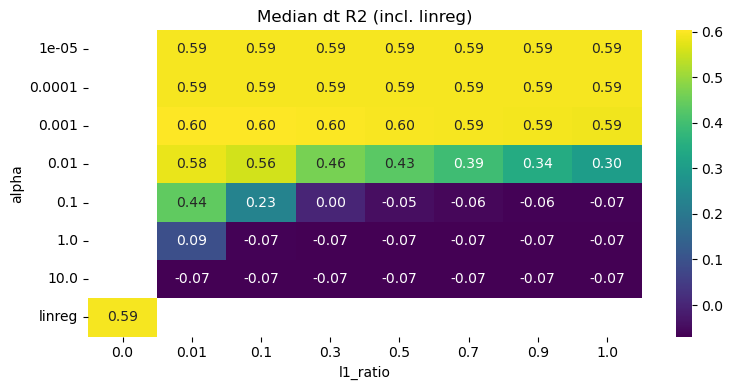

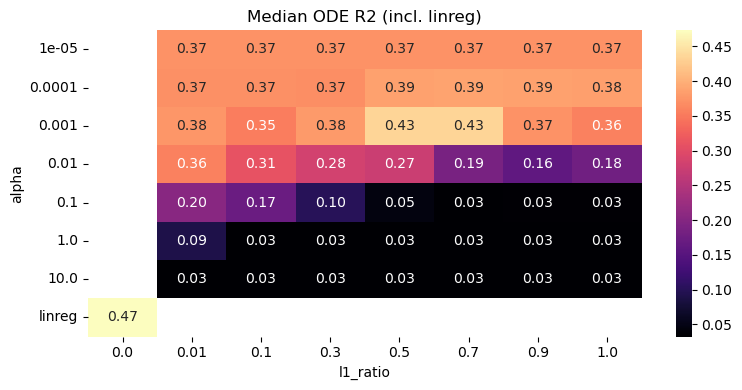

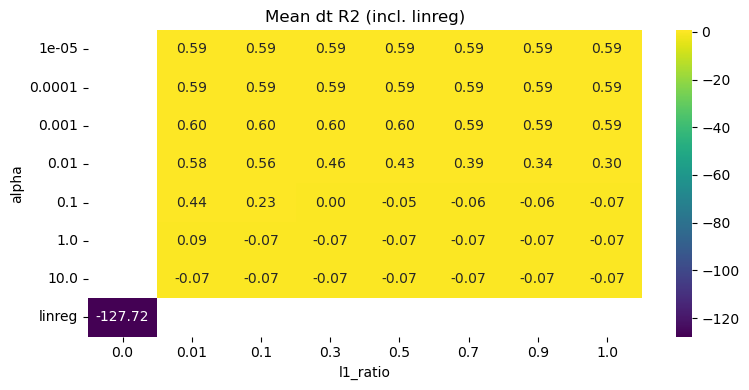

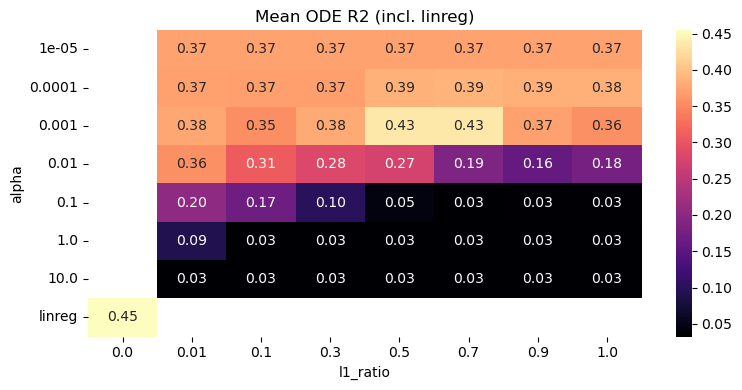

In [13]:
# Median/mean R2 heatmaps with baseline Linear Regression row
from sklearn.linear_model import LinearRegression

# Compute baseline linreg metrics across markers
lin_dt = []
lin_ode = []
for marker in markers:
    subset = df[df['marker'] == marker].copy()
    subset = subset.dropna(subset=feature_columns + ['p_ERK1_2_dt', 'GFP_bin', 'timepoint'])
    if subset.empty:
        continue
    train_bins, test_bins = choose_bin_split(subset, test_size=test_size, random_state=random_state)
    if not train_bins or not test_bins:
        continue
    train_df = subset[subset['GFP_bin'].isin(train_bins)].copy()
    test_df = subset[subset['GFP_bin'].isin(test_bins)].copy()
    if dataset_mode == 'per_minute':
        time_arr = pd.to_numeric(test_df.get('timepoint'), errors='coerce').to_numpy()
        mask_measured = np.isin(time_arr, measured_timepoints)
        test_df = test_df[mask_measured] if mask_measured.any() else test_df.iloc[:0]
    if train_df.empty or test_df.empty:
        continue
    pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
    X_train = train_df[feature_columns].to_numpy(dtype=float)
    y_train = train_df['p_ERK1_2_dt'].to_numpy(dtype=float)
    X_test = test_df[feature_columns].to_numpy(dtype=float)
    y_test = test_df['p_ERK1_2_dt'].to_numpy(dtype=float)
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)
    # dt R2
    if len(y_test) > 1:
        num = ((y_test - y_pred_test) ** 2).sum()
        den = ((y_test - y_test.mean()) ** 2).sum()
        dt_r2 = 1 - num/den if den > 0 else np.nan
    else:
        dt_r2 = np.nan
    lin_dt.append(dt_r2)
    # ODE R2 via integrate_marker_ode
    test_eval = test_df.copy()
    test_eval['__y_pred__'] = y_pred_test
    obs_p_raw = test_eval.get('p_ERK1_2', test_eval.get('p-ERK1-2'))
    obs_p = pd.to_numeric(obs_p_raw, errors='coerce') if obs_p_raw is not None else pd.Series(np.nan, index=test_eval.index)
    state_bounds = _compute_percentile_interval(obs_p.to_numpy(dtype=float), ODE_STATE_PERCENTILES, ODE_STATE_MARGIN_FRAC, (ODE_TSIT5_STATE_MIN, ODE_TSIT5_STATE_MAX))
    state_transform = StateTransform('identity', state_bounds)
    deriv_clip = _compute_percentile_interval(pipe.predict(X_train), ODE_DERIV_PERCENTILES, ODE_DERIV_MARGIN_FRAC, (-1e6, 1e6))
    model = pipe.named_steps['model']
    expr = _format_formula(model.coef_, feature_columns, model.intercept_)
    expr = sanitize_formula(expr, safe_division_eps=None)
    formula_fn_np, symbols = make_formula_function(expr, backend='numpy')
    ode_metrics, ode_trajs = integrate_marker_ode(
        test_eval, 'p_ERK1_2_dt', measured_timepoints, dataset_mode, formula_fn_np, symbols, p_symbol,
        formula_fn_fallback=formula_fn_np, feature_clip_percentiles=ODE_FEATURE_CLIP, anchor_alpha=0.0,
        anchor_adaptive_scale=0.0, state_transform=state_transform, deriv_clip=deriv_clip, prefer_radau=False,
        include_trajectories=True, phase='test'
    )
    ode_r2 = ode_metrics.get('ode_integ_r2_median')
    if ode_r2 is None or (isinstance(ode_r2, float) and np.isnan(ode_r2)):
        try:
            df_traj = pd.DataFrame(ode_trajs)
            if 'phase' in df_traj.columns:
                df_traj = df_traj[df_traj['phase'] == 'test']
            obs = pd.to_numeric(df_traj.get('obs_pERK1_2'), errors='coerce')
            pred = pd.to_numeric(df_traj.get('pred_integrated_ode'), errors='coerce')
            tvals = pd.to_numeric(df_traj.get('timepoint'), errors='coerce')
            mask = np.isfinite(obs) & np.isfinite(pred) & np.isfinite(tvals)
            if dataset_mode == 'per_minute':
                mask = mask & np.isin(tvals, measured_timepoints)
            if mask.sum() >= 2:
                ode_r2 = float(np.corrcoef(obs[mask], pred[mask])[0,1] ** 2)
        except Exception:
            pass
    lin_ode.append(ode_r2)

lin_row = {'alpha': 'linreg', 'l1_ratio': 0, 'dt_r2_median': np.nanmedian(lin_dt) if lin_dt else np.nan,
           'ode_r2_median': np.nanmedian(lin_ode) if lin_ode else np.nan,
           'dt_r2_mean': np.nanmean(lin_dt) if lin_dt else np.nan,
           'ode_r2_mean': np.nanmean(lin_ode) if lin_ode else np.nan}
grid_ext = grid_df.copy()
grid_ext['dt_r2_mean'] = grid_ext['dt_r2_median']  # placeholder: mean not stored originally
grid_ext['ode_r2_mean'] = grid_ext['ode_r2_median']
grid_ext = pd.concat([grid_ext, pd.DataFrame([lin_row])], ignore_index=True)

def _heat(df, value_col, title, cmap='viridis'):
    pivot = df.pivot(index='alpha', columns='l1_ratio', values=value_col)
    plt.figure(figsize=(8,4))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap)
    plt.title(title)
    plt.tight_layout()

_heat(grid_ext, 'dt_r2_median', 'Median dt R2 (incl. linreg)')
_heat(grid_ext, 'ode_r2_median', 'Median ODE R2 (incl. linreg)', cmap='magma')
_heat(grid_ext, 'dt_r2_mean', 'Mean dt R2 (incl. linreg)')
_heat(grid_ext, 'ode_r2_mean', 'Mean ODE R2 (incl. linreg)', cmap='magma')
